In [1]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

Install the required environment through requirements.txt

In [2]:
#!pip install -r requirements.txt


In [2]:
# Initialize the agent state
from typing import Literal, Optional, List, Dict, Any, Type
from langgraph.graph import MessagesState


class State(MessagesState):
    user_query: Optional[str]
    enabled_agents: Optional[List[str]] # Makes our multi-agent systsem modular on which agents to include
    plan: Optional[List[str]] 
    current_step: int # Making the current step in the plan
    agent_query: Optional[str] # Inbox note: `agent_query` tells the next agent exactly what to do at current step
    last_reason: Optional[str] # Explains the executor's decision to help maintain continuity and provide traceability.
    replan_flag: Optional[bool] # Set by the executor to indicate that the planner should revise the plan.
    replan_attempts: Optional[Dict[int, Dict[int, int]]] # Replan attempts tracked per step number.

# Create planner
The planner consists of a sequence of numbered steps, each step includes the action and the sub-agent that is assigned to that action.

In [3]:
from prompts import plan_prompt
from langgraph.types import Command
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

import json

In [4]:
reasoning_llm = ChatOpenAI(
    model="o3",
    model_kwargs = {"response_format": {"type": "json_object"}},
)

In [5]:
def planner_node(state: State) -> Command[Literal['executor']]:
    """
    from sqlalchemy.dialects.postgresql import Any
    from multiprocessing.sharedctypes import Value
    Run the planning LLM and stores the resulting plan in state
    """
    # 1. invoke LLM with the planner prompt
    llm_reply = reasoning_llm.invoke([plan_prompt(state)])

    # 2. Vlidate JSON
    try:
        content_str = llm_reply.content if isinstance(
            llm_reply.content, str ) else str(llm_reply.content)
        parsed_plan = json.loads(content_str)
    except json.JSONDecodeError:
        raise ValueError(f"Planner returned invalid JSON:\n{llm_reply.content}" )

    # 3. Store as current plan only
    replan = state.get("replan_flag", False)
    updated_plan: Dict[str, Any] = parsed_plan

    return Command(
        update={
            "plan": updated_plan,
            "messages": [HumanMessage(
                content=llm_reply.content,
                name='replan' if replan else 'inital_plan'
            )],
            "user_query": state.get('user_query', state['messages'][0].content),
            "current_step": 1 if not replan else state['current_step'],
            "replan_flag": state.get("replan_flag", False),
            "last_reason": "",
            "enabled_agents": state.get("enabled_agents")
        },
        goto="executor"
    )


# Create executor
The executor executes the plan by identifying the sub-agent that should go next and generating the instructions (or agent query) for the chosen agent. Based on the results of the retrieval step (web search results in this case), the executor might decide that the plan needs to be changed. In this case, it goes bck to the planner and asks it go generate an updated plan.

In [6]:
from prompts import executor_prompt
from langgraph.graph import END

MAX_REPLANS = 3

In [7]:
'''
from multiprocessing.sharedctypes import Value
Command is a Langgraph class that lets a node control the graph's routing. A retrun type from a node that does thow things at once 
1. Updates the state (via update = {})
2. Routes to the next node (via goto="...")
''' 
def executor_node(state: State) -> Command[Literal["web_researcher", "chart_generator", "synthesizer", "planner"]]:
    plan: Dict[str, Any] = state.get("plan", {})
    step: int = state.get("current_step", 1)

    #0) If we just replanned, run the planned agent once before reconsidering
    if state.get('replace_flag'):
        planned_agent = plan.get(str(step), {}).get('agent')
        return Command(
            update={
                "replan_flag": False,
                "current_step": step+1,
            },
            goto=planned_agent
        )
    #1) Build prompt & call LLM
    llm_reply = reasoning_llm.invoke([executor_prompt(state)])
    try:
        content_str = llm_reply.content if isinstance(llm_reply.content, str) else str(llm_reply.content)
        parsed = json.loads(content_str)
        replan: bool = parsed['replan']
        goto: str = parsed['goto']
        reason: str = parsed['reason']
        query: str = parsed['query']
    except Exception as exp:
        raise ValueError(f"Invalid executor JSON:\n{llm_reply.content}") from exp

    # Update the state
    updates: Dict[str, Any] = {
        "messages": [HumanMessage(content=llm_reply.content, name='executor')],
        "last_reason": reason,
        "agent_query": query
    }

    # Replan accounting
    replans: Dict[int, int] = state.get("replan_attempts", {}) or {}
    step_replans = replans.get(step, 0)

    #2) Replan decision
    if replan:
        if step_replans < MAX_REPLANS:
            replans[step] = step_replans + 1
            updates.update({
                "replan_attempts": replans,
                "replan_flag": False,
                "current_step": step
            })
            return Command(update=updates, goto="planner")
        else:
            next_agent = plan.get(str(step+1), {}).get("agent", "synthesizer")
            updates['current_step'] = step+1
            return Command(update=updates, goto=next_agent)

    #3) Happy path: run chosen agent; advance only if follwing the plan
    planned_agent = plan.get(str(step), {}).get("agent")
    updates["current_step"] = step+1 if goto==planned_agent else step
    updates["replan_flag"] = False
    return Command(update=updates, goto=goto)

    

# Create Web research Agent
The web research sub-agent is a ReAct agent that uses Tavily Search tool to search the web and answer the sub-query assigned to it.

In [8]:
from langgraph.prebuilt import create_react_agent
from typing import Literal
from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI

In [11]:
tavily_tool = TavilySearch(max_results=5)
tavily_tool.invoke("What is Helsinki's weather today?")["results"]

[{'title': 'Weather in Helsinki',
  'url': 'https://www.weatherapi.com/',
  'content': "{'location': {'name': 'Helsinki', 'region': 'Southern Finland', 'country': 'Finland', 'lat': 60.176, 'lon': 24.934, 'tz_id': 'Europe/Helsinki', 'localtime_epoch': 1774207109, 'localtime': '2026-03-22 21:18'}, 'current': {'last_updated_epoch': 1774206900, 'last_updated': '2026-03-22 21:15', 'temp_c': 3.3, 'temp_f': 37.9, 'is_day': 0, 'condition': {'text': 'Partly Cloudy', 'icon': '//cdn.weatherapi.com/weather/64x64/night/116.png', 'code': 1003}, 'wind_mph': 13.9, 'wind_kph': 22.3, 'wind_degree': 223, 'wind_dir': 'SW', 'pressure_mb': 1016.0, 'pressure_in': 30.0, 'precip_mm': 0.0, 'precip_in': 0.0, 'humidity': 75, 'cloud': 0, 'feelslike_c': -1.4, 'feelslike_f': 29.5, 'windchill_c': -3.2, 'windchill_f': 26.3, 'heatindex_c': 1.9, 'heatindex_f': 35.4, 'dewpoint_c': -1.9, 'dewpoint_f': 28.5, 'vis_km': 10.0, 'vis_miles': 6.0, 'uv': 0.0, 'gust_mph': 24.2, 'gust_kph': 38.9}}",
  'score': 0.9897051,
  'raw_con

In [12]:
from helper import agent_system_prompt
llm = ChatOpenAI(model="gpt-4o")

web_search_agent = create_react_agent(
    llm,
    tools=[tavily_tool],
    prompt=agent_system_prompt(f"""
        You are the researcher. You can only perform research by using the provided search tool (travity_tool). When you have found the necessary information, end your output. Don't attempt to take further actions.
    """)
)

In [13]:
def web_search_node(
    state: State
) -> Command[Literal["executor"]]:
    agent_query = state.get("agent_query")
    result = web_search_agent.invoke({"messages": agent_query})
    goto = "executor"
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="web_researcher")
    return Command(
        update={
            # share internal message history of research agent with other agents
            "messages": result['messages'],
        },
        goto=goto
    )

In [13]:
agent_response = web_search_agent.invoke({
    "messages": "What is Helsinki's weather today?"
})
agent_response['messages'][-1].content

'Today in Helsinki, the weather is clear with a temperature of approximately 4.2°C (39.6°F). The wind is coming from the southwest at a speed of about 23 km/h (14.3 mph). The humidity level is around 65%, and there is no precipitation at the moment. It feels like -0.3°C (31.5°F) due to the wind chill. The visibility is about 10 km (6 miles), and the UV index is 0.'

# Create charting agent
If the user asks for the results to be charted, then the charting sub-agent can help with that. It first generates the Python code that generates the chart, and then executes the code using the `python_repl_tool`.

In [14]:
from helper import python_repl_tool

# Chart generator agent and node
chart_agent = create_react_agent(
    llm,
    [python_repl_tool],
    prompt = agent_system_prompt(
        """
        You can only generate charts. You are working with a researcher 
        colleague.
        1) Print the chart first.
        2) Save the chart to a file in the current working directory.
        3) At the very end of your message, output EXACTLY two lines 
        so the summarizer can find them:
           CHART_PATH: <relative_path_to_chart_file>
           CHART_NOTES: <one concise sentence summarizing the main insight in the chart>
        Do not include any other trailing text after these two lines.
        """
    ),
)

In [15]:
def chart_node(state: State) -> Command[Literal["chart_summarizer"]]:
    result = chart_agent.invoke(state)
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name = "chart_generator"
    )
    goto="chart_summarizer"
    return Command(
        update={
            "messages": result["messages"]
        },
        goto=goto
    )

# Create chart summary agent
This sub-agent generates a caption describing the chart generated by the chart generator.

In [16]:

chart_summary_agent = create_react_agent(
    llm,
    tools=[],
    prompt=agent_system_prompt(
        "You can only generate image captions. You are working with a researcher colleague and a chart generator colleague. "
        + "Your task is to generate a standalone, concise summary for the provided chart image saved at a local PATH, where the PATH should be and only be provided by your chart generator colleague. The summary should be no more than 3 sentences and should not mention the chart itself."

    ),
)

In [17]:
def chart_summary_node(state: State) -> Command[Literal[END]]:
    result = chart_summary_agent.invoke(state)
    print(f"Chart summarizer answer: {result['messages'][-1].content}")
    # Send to the end node
    goto= END
    return Command(
        update={
            "messages": result["messages"],
            "final_answer": result["messages"][-1].content,
        },
        goto=goto
    )

# Create a Synthesizer (Text Summarizer) Agent
In the case where the user does not ask for the results to be charted, the synthesizer sub-agent generates text that summarizes the retrieved results. In this case, it's the web research results.

In [18]:
llm = ChatOpenAI(model="gpt-4o")

In [18]:
def synthesizer_node(state: State) -> Command[Literal[END]]:
    """
    Creates a concise, human-readable summary of the entire interaction,
    **purely in prose**.

    It ignores structured tables or chart IDs and instead rewrites the
    relevant agent messages (research results, chart commentary, etc.)
    into a short final answer.
    """

    # Gather informations messages for final synthesis
    relevant_msgs = [
        m.content for m in state.get("messages", []) if getattr(m, "name", None) in ("web_researcher", "chart_generator", "chart_summarizer")
    ]

    user_question = state.get("user_query", state.get("messages", [{}]))

    synthesis_instructions = (
        """
        You are the Synthesizer. Use the context below to directly 
        answer the user's question. Perform any lightweight calculations, 
        comparisons, or inferences required. Do not invent facts not 
        supported by the context. If data is missing, say what's missing
        and, if helpful, offer a clearly labeled best-effort estimate 
        with assumptions.\n\n
        Produce a concise response that fully answers the question, with 
        the following guidance:\n
        - Start with the direct answer (one short paragraph or a tight bullet list).\n
        - Include key figures from any 'Results:' tables (e.g., totals, top items).\n
        - If any message contains citations, include them as a brief 'Citations: [...]' line.\n
        - Keep the output crisp; avoid meta commentary or tool instructions.
        """
    )

    summary_prompt = [
        HumanMessage(content=(
            f"User question: {user_question}\n\n"
            f"{synthesis_instructions}\n\n"
            f"Context:\n\n" + "\n\n---\n\n".join(relevant_msgs)
        ))
    ]

    llm_reply = llm.invoke(summary_prompt)

    answer = llm_reply.content.strip()
    print(f"Synthesizer answer: {answer}")

    return Command(
        update={
            "final_answer": answer,
            "messages": [HumanMessage(content=answer, name="synthesizer")],
        },
        goto=END,           # hand off to the END node
    )

Build the agent graph

In [19]:
from langgraph.graph import START, StateGraph

workflow = StateGraph(State)
workflow.add_node("planner", planner_node)
workflow.add_node("executor", executor_node)
workflow.add_node("web_researcher", web_search_node)
workflow.add_node("chart_generator", chart_node)
workflow.add_node("chart_summarizer", chart_summary_node)
workflow.add_node("synthesizer", synthesizer_node)

workflow.add_edge(START, "planner")

graph = workflow.compile()

In [21]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_png()))

ImportError: Install pygraphviz to draw graphs: `pip install pygraphviz`.

Query: Chart the current market capitalization of the top 5 banks in the US?


Python REPL can execute arbitrary code. Use with caution.


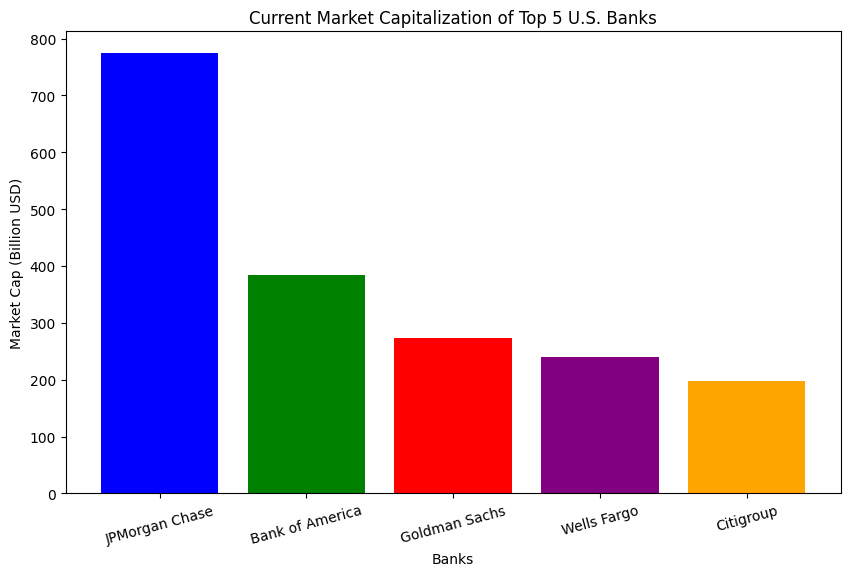

Chart summarizer answer: JPMorgan Chase leads significantly with a market capitalization of $773.79 billion, followed by Bank of America at $383.74 billion, and Goldman Sachs at $274 billion. Wells Fargo and Citigroup trail behind with $239.45 billion and $198.35 billion, respectively. These figures highlight JPMorgan Chase's commanding presence in the U.S. banking sector.
--------------------------------


In [20]:
from langchain.schema import HumanMessage
import json

query = "Chart the current market capitalization of the top 5 banks in the US?"
print(f"Query: {query}")

state = {
            "messages": [HumanMessage(content=query)],
            "user_query": query,
            "enabled_agents": ["web_researcher", "chart_generator", 
                               "chart_summarizer", "synthesizer"],
        }
graph.invoke(state)

print("--------------------------------")

In [21]:
query = "Identify current regulatory changes for the financial services industry in the US."
print(f"Query: {query}")

state = {
            "messages": [HumanMessage(content=query)],
            "user_query": query,
            "enabled_agents": ["web_researcher", "chart_generator", 
                               "chart_summarizer", "synthesizer"],
        }
graph.invoke(state)

print("--------------------------------")

Query: Identify current regulatory changes for the financial services industry in the US.
Synthesizer answer: - **SEC**: Proposed eliminating the quarterly reporting requirement, allowing companies to report biannually. They have also enacted rules defining certain crypto assets as securities.
- **OCC**: Finalized a rewrite of Basel rules, decreasing capital requirements for traditional banks in collaboration with the Fed and FDIC.
- **Federal Reserve**: Proposed loosening capital requirements for large banks by 4.8%.
- **CFPB**: Secured a court order for continued funding amidst governmental challenges.
- **CFTC**: Issued guidance, along with the SEC, declaring most crypto assets are not securities, providing clarity in the crypto markets. They also proposed seeking public input on prediction markets to address market manipulation risks.
- **FDIC**: Finalized a rule adjusting deposit insurance coverage affecting insured banks' operations after acquiring failed banks.

Citations: [WSJ]